In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
from networkx.algorithms.community import greedy_modularity_communities
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

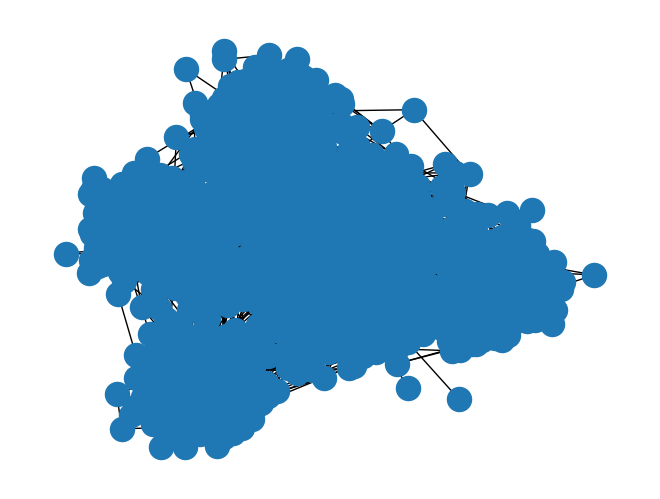

In [2]:
network_graph = nx.read_edgelist("input/edges_train.edgelist", data=False, nodetype = int, delimiter=',') 
pos = nx.spring_layout(network_graph)
nx.draw(network_graph, pos=pos)

In [3]:
N = len(list(network_graph.nodes))
print("The network has ", N, " nodes")

E = len(list(network_graph.edges))
print("The network has ", E, " edges")

The network has  1800  nodes
The network has  6377  edges


Remove 10% of the positive edges to use for training as the test set has done the same. 

In [4]:
nEdgesRemove = 640 

# Sample random edges
allEdges = np.array(network_graph.edges) # all positive edges 
np.random.seed(seed=42)
selectEdges = np.random.choice(np.arange(allEdges.shape[0]), nEdgesRemove, replace=False) # select 640 random indicies 
edgesToRemove = allEdges[selectEdges]

# Create new graph without selected edges
graph_train = network_graph.copy()
graph_train.remove_edges_from(edgesToRemove)

#Compute number of nodes in the network
N = len(list(graph_train.nodes))
print("The network has ", N, " nodes")

#Compute number of edges in the network
E = len(list(graph_train.edges))
print("The network has ", E, " edges")

The network has  1800  nodes
The network has  5737  edges


Sample 640 negative examples from non-connected node pairs so the training set is balanced as the test set

In [5]:
node_pairs = []
Y = []

# Add positive examples where edge exist (edges that are removed from graph_train)
for (i, j) in edgesToRemove:
    node_pairs.append((i, j))
    Y.append(1) # node connection exists 

# Add negative examples where edge does not exist (pairs of nodes with no edges connecting them)
negatives = set()
while len(negatives) < 640:
        i, j = np.random.randint(N, size=2) # creates a random edge
        if i != j and not network_graph.has_edge(i,j):
              negatives.add((min(i,j), max(i,j)))

negatives = list(negatives)             
node_pairs = node_pairs + negatives
Y = Y + [0] * len(negatives)

"Previous research in social sciences has revealed important regularities in social networks, which indicates that missing connections can possible be predicted: the clustering coefficient of social networks is high, meaning that if two individuals have a have a friend in common there is a high probability they are also connected" - shared neighbors 

"in social networks we observe homophily, meaning that connected individuals tend to be similar" - node attributes

"inally, networks reveal well-defined communities" - same community

In [6]:
attr = pd.read_csv('input/attributes.csv', index_col='ID')['attribute']
print(attr.value_counts())

def get_features(G, pairs):
    jc = [p for _, _, p in nx.jaccard_coefficient(G, pairs)]
    aa = [p for _, _, p in nx.adamic_adar_index(G, pairs)]
    cn = [len(list(nx.common_neighbors(G, u, v))) for u, v in pairs]
    same_attr = [int(attr[u] == attr[v]) for u, v in pairs]

    communities = greedy_modularity_communities(G)
    comm_dict = {n: k for k, c in enumerate(communities) for n in c}
    same_comm = [int(comm_dict[u] == comm_dict[v]) for u, v in pairs]
    return np.column_stack([cn, jc, aa, same_attr, same_comm])

X = get_features(graph_train, node_pairs)   

attribute
f    300
b    300
c    300
a    300
e    300
d    300
Name: count, dtype: int64


Creating a train-and-test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state = 42)


Finding the best model using GridSearchCV and cross validation.

In [8]:
# Logistic Regression
param_grid_lg = {'logisticregression__C': [0.001, 0.01, 0.1, 1.0, 10, 100]}

model_lg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
grid_lg = GridSearchCV(model_lg, param_grid_lg, cv=5, scoring='accuracy')
grid_lg.fit(X_train, y_train)

print(f"CV score Logistic Regression: {grid_lg.best_score_}")

# Desicion Tree
param_grid_dt = {'max_depth': [2, 4, 6, 8, 10, None],
                'min_samples_split': [2, 5, 10, 20]}

model_dt = DecisionTreeClassifier(random_state=42)
grid_dt = GridSearchCV(model_dt, param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

print(f"CV score Decision Tree: {grid_dt.best_score_}")

# KNearestNeighbors
param_grid_knn = {'kneighborsclassifier__n_neighbors': [5, 11, 21, 41, 81],
                  'kneighborsclassifier__weights': ['uniform', 'distance']}

model_knn = make_pipeline(StandardScaler(), KNeighborsClassifier())
grid_knn = GridSearchCV(model_knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

print(f"CV KNearestNeighbors: {grid_knn.best_score_}")

CV score Logistic Regression: 0.8447441415590629
CV score Decision Tree: 0.8359588713534194
CV KNearestNeighbors: 0.8496269727403156


From the mean test score and standard deviation in the test score we see that the models perform about equally as well. We choose Logistic Regression since it is simple and has interpretable coefficients. 

In [9]:
for name, grid in [("LR", grid_lg), ("DT", grid_dt), ("kNN", grid_knn)]:
    i = grid.best_index_
    print(name, grid.cv_results_["mean_test_score"][i].round(3),
          "±", grid.cv_results_["std_test_score"][i].round(3))

LR 0.845 ± 0.039
DT 0.836 ± 0.039
kNN 0.85 ± 0.035


Checking the contributions of the coefficients. 

In [10]:
lr = grid_lg.best_estimator_.named_steps['logisticregression']
feature_names = ["cn", "jc", "aa", "same_attr", "same_comm"]
for name, coef in zip(feature_names, lr.coef_[0]):
    print(f"{name:10s} {coef:.3f}")

cn         0.102
jc         0.103
aa         0.095
same_attr  0.119
same_comm  0.246


The coefficients are strongly shrunk towards zero, probably due to a small C

Accuracy (test): 0.871



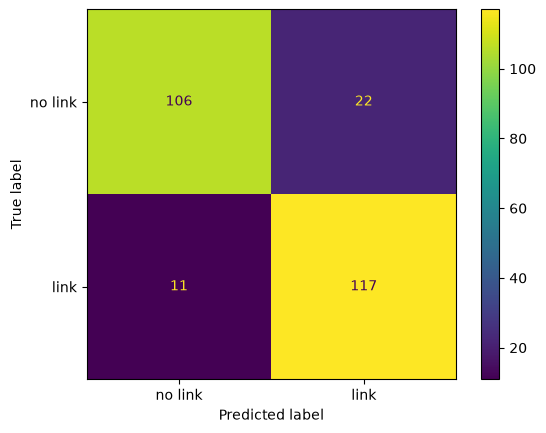

              precision    recall  f1-score   support

     no link       0.91      0.83      0.87       128
        link       0.84      0.91      0.88       128

    accuracy                           0.87       256
   macro avg       0.87      0.87      0.87       256
weighted avg       0.87      0.87      0.87       256



In [11]:
y_pred = grid_lg.best_estimator_.predict(X_test)
print(f"Accuracy (test): {accuracy_score(y_test, y_pred):.3f}\n")

cm = confusion_matrix(y_test, y_pred, labels=grid_lg.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["no link", "link"])
disp.plot()
plt.show()

print(classification_report(y_test, y_pred, target_names=["no link", "link"]))


Investigating the scores for each value of C

In [12]:
for C, score, std in zip(grid_lg.cv_results_["param_logisticregression__C"],
                         grid_lg.cv_results_["mean_test_score"],
                         grid_lg.cv_results_["std_test_score"]):
    print(f"C={C:<7} {score:.3f} ± {std:.3f}")

C=0.001   0.845 ± 0.039
C=0.01    0.842 ± 0.040
C=0.1     0.844 ± 0.041
C=1.0     0.844 ± 0.041
C=10.0    0.844 ± 0.041
C=100.0   0.844 ± 0.041


We look at the coefficients for C=1 to get a better interpretation

In [13]:
lr_interp = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
lr_interp.fit(X_train, y_train)
for name, coef in zip(feature_names, lr_interp.named_steps['logisticregression'].coef_[0]):
    print(f"{name:10s} {coef:.3f}")

cn         0.800
jc         -0.055
aa         0.564
same_attr  0.127
same_comm  1.377


same_comm acts as a proxy for same_attr. It explains why the attribute has a small coefficient in the model: most of its information is already captured by the community feature. As a result, the attribute influences the predictions more than its own coefficient suggests, and removing same_attr would not prevent the model from using it indirectly

In [14]:
communities = greedy_modularity_communities(graph_train)
comm_dict = {n: k for k, c in enumerate(communities) for n in c}
comm_series = pd.Series(comm_dict).sort_index()

print(pd.crosstab(comm_series, attr))

attribute    a    b    c    d    e    f
row_0                                  
0            9   16  223   16   20   19
1           14  225   18   18   20    8
2           12   21   15   20  217   17
3           16   18   13  218   16   20
4           14   11   20   13   16  224
5          235    8   11   15   11   12
6            0    1    0    0    0    0


Predicting if new links belong to the network or not using solutionInput.csv. The model predicts 54.7% of the pairs as links (775 of 1416), slightly above the true 50%. This agrees with the behaviour on our own test set, where the model predicted 54% links because its recall for links (0.91) is higher than for non-links (0.83).

In [15]:
inputTest = pd.read_csv('input/solutionInput.csv', index_col='ID')[['int1', 'int2']]
test_pairs = list(inputTest.itertuples(index=False, name=None))

X_final = get_features(network_graph, test_pairs)
predictions = grid_lg.best_estimator_.predict(X_final)

print(len(predictions), predictions.mean())  

1416 0.547316384180791


In [16]:
pd.DataFrame({'prediction': predictions}, index=inputTest.index) \
  .to_csv('predictions.csv', index_label='ID')